In [11]:
# ============================================================
"""
Script: bem_L2_vs_k.py

Description:
    Computes the BEM solution for different wavenumbers k
    and evaluates the relative L2 error against the analytical solution.
    Produces a plot of L2 error vs k.
"""
# ============================================================

#%% ======================== IMPORTS ========================
from datetime import datetime
import sys
import os
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import plotting_functions
# Paths
current_dir = os.getcwd()
utilities_dir = os.path.join(current_dir, '../../utilities')
os.chdir(current_dir)
sys.path.insert(0, utilities_dir)

# Import modules
from analytical_solution_functions import sound_hard_circle_calc, mask_displacement
from bem_solution_functions import Circle_n, solveExteriorBoundary, solveExterior, generateInteriorPoints_excluding_circle


In [36]:
#%% ======================== PARAMETERS ========================

# Geometry
r_exclude = np.pi / 4
l_se = np.pi
n_dom = 40
n_grid = 501

# Wavenumber study
k_values = np.linspace(1, 10, 10)
bem_k_values = np.linspace(1, 10, 10)
l2_errors = []

# Grid (same for all k)
Y, X = np.mgrid[-l_se:l_se:n_grid*1j, -l_se:l_se:n_grid*1j]
R_grid = np.sqrt(X**2 + Y**2)

# Interior points
points_outside, _ = generateInteriorPoints_excluding_circle(
    Nx=n_dom, Ny=n_dom,
    xmin=-l_se, xmax=l_se,
    ymin=-l_se, ymax=l_se,
    r_exclude=r_exclude
)
interiorIncidentPhi = np.zeros(points_outside.shape[0], dtype=complex)


In [40]:
#%% ======================== LOOP OVER k ========================

for k in k_values:

    print(f"\nSolving for k = {k:.2f}")

    # ------------------ Adaptive discretization ------------------
    n = int(10 * k)   # points per wavelength (important!)
    aVertex, aElement = Circle_n(n=n, radius=r_exclude)

    num_elements = aElement.shape[0]
    aCenters = 0.5 * (aVertex[aElement[:, 0]] + aVertex[aElement[:, 1]])
    theta = np.arctan2(aCenters[:, 1], aCenters[:, 0])

    # ------------------ Boundary conditions ------------------
    alpha = np.zeros(num_elements, dtype=complex)
    beta  = np.ones(num_elements, dtype=complex)

    kx = k * aCenters[:, 0]
    phi_inc = np.exp(1j * kx)
    f = -1j * k * np.cos(theta) * phi_inc

    phi = np.zeros(num_elements, dtype=complex)
    v   = np.zeros(num_elements, dtype=complex)

    # ------------------ Solve BEM ------------------
    c, density = None, None
    v, phi = solveExteriorBoundary(
        k, alpha, beta, f, phi, v,
        aVertex, aElement,
        c, density,
        'exterior'
    )

    # ------------------ Evaluate field ------------------
    interiorPhi = solveExterior(
        k, v, phi,
        interiorIncidentPhi,
        points_outside,
        aVertex, aElement,
        'exterior'
    )

    # ------------------ Interpolation ------------------
    grid_z = griddata(points_outside, interiorPhi, (X, Y), method='cubic')
    grid_z = np.ma.masked_where(R_grid < r_exclude, grid_z)

    u_scn_amp = grid_z.real

    # ------------------ Analytical solution ------------------
    _, u_scn_exact, _ = sound_hard_circle_calc(k, r_exclude, X, Y)
    u_scn_exact = mask_displacement(R_grid, r_exclude, l_se, u_scn_exact)

    # ------------------ L2 error ------------------
    u_exact_masked = np.copy(u_scn_exact)
    u_num_masked   = np.copy(u_scn_amp)

    u_exact_masked[R_grid < r_exclude] = 0
    u_num_masked[R_grid < r_exclude] = 0

    rel_L2 = np.linalg.norm(u_exact_masked.real - u_num_masked.real, 2) / \
             np.linalg.norm(u_exact_masked.real, 2)

    print(f"k = {k:.2f}, L2 error = {rel_L2:.3e}")

    l2_errors.append(rel_L2)
np.save("data/bem_L2_errors_wavenumbers.npy", np.array(l2_errors))



Solving for k = 1.00
k = 1.00, L2 error = 3.312e-02

Solving for k = 2.00
k = 2.00, L2 error = 2.079e-02

Solving for k = 3.00
k = 3.00, L2 error = 2.476e-02

Solving for k = 4.00
k = 4.00, L2 error = 2.059e-02

Solving for k = 5.00
k = 5.00, L2 error = 2.403e-02

Solving for k = 6.00
k = 6.00, L2 error = 3.139e-02

Solving for k = 7.00
k = 7.00, L2 error = 3.223e-02

Solving for k = 8.00
k = 8.00, L2 error = 3.439e-02

Solving for k = 9.00
k = 9.00, L2 error = 6.605e-02

Solving for k = 10.00
k = 10.00, L2 error = 8.966e-02


In [41]:
l2_errors

[0.03311766390000465,
 0.0207871991714413,
 0.024761772825333508,
 0.020594558849072884,
 0.024029028105870605,
 0.03138660768439689,
 0.03222943162798155,
 0.034385359467682716,
 0.06604781272259885,
 0.08966008203183196]

/tmp/ipykernel_40227/2420370707.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


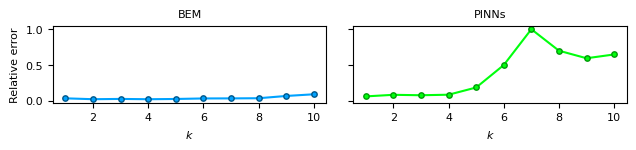

In [61]:
# Load PINNs data
pinns_l2_errors = np.load("data/pinns_L2_errors_wavenumbers_2026-04-06_15-57-09.npy")
pinns_k_values = np.linspace(1, 10, 10)

fig, axs = plt.subplots(1, 2, figsize=(7.4, 1.0), sharey=True,gridspec_kw={'wspace': 0.1})
    
# -------------------- BEM --------------------
axs[0].plot(bem_k_values, l2_errors, color="#00a2ff", zorder=1)
axs[0].scatter(bem_k_values, l2_errors, s=15, color="#00a2ff",
               edgecolor="#00578a", zorder=2)

axs[0].set_xlabel("$k$")
axs[0].set_ylabel("Relative error")
#axs[0].set_yscale("log")
#axs[0].set_yticks([1e-2, 1e-1, 1e0])
#axs[0].set_ylim(1e-2, 1e0)
axs[0].set_title("BEM", fontsize=8)

# -------------------- PINNs --------------------
axs[1].plot(pinns_k_values, pinns_l2_errors, color="#00ff0d", zorder=1)
axs[1].scatter(pinns_k_values, pinns_l2_errors, s=15, color="#00ff0d",
               edgecolor="#009908", zorder=2)

axs[1].set_xlabel("$k$")
#axs[1].set_yscale("log")
axs[1].set_title("PINNs", fontsize=8)

# -------------------- Layout --------------------
plt.tight_layout()

os.makedirs("figures", exist_ok=True)
plt.savefig("figures/bem_vs_pinns_L2_vs_k.svg", dpi=300, bbox_inches='tight')
plt.show()

In [58]:
pinns_l2_errors

array([0.06019594, 0.08235308, 0.07624635, 0.08372376, 0.18466339,
       0.49889343, 0.9998564 , 0.69926952, 0.59383239, 0.64674229])